In [1]:
# 🔬 Análise de Interações Medicamentosas

#**Autor:** Rafael  
#**Ferramentas:** Python · pandas · pyvis · matplotlib · seaborn  
#**Dados:** 50 pares de fármacos com gravidade, mecanismo e conduta clínica

## 🎯 Contexto clínico

#Interações medicamentosas estão entre as principais causas de internações
#evitáveis no Brasil. Este projeto analisa 50 pares de fármacos classificados
#por gravidade e mecanismo, gerando visualizações para apoio à prática clínica.

In [2]:
# Rode esta célula apenas uma vez e reinicie o kernel depois
import sys
!{sys.executable} -m pip install pyvis pandas matplotlib seaborn --quiet

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Carregar dados
df = pd.read_csv("interacoes_medicamentosas.csv", encoding="latin-1")
df["gravidade"] = df["gravidade"].str.strip()

print(f"✅ Dataset carregado com sucesso!")
print(f"   {df.shape[0]} interações · {df.shape[1]} colunas")
print(f"\nColunas: {df.columns.tolist()}")
df.head(8)

✅ Dataset carregado com sucesso!
   50 interações · 5 colunas

Colunas: ['farmaco_1', 'farmaco_2', 'gravidade', 'mecanismo', 'conduta']


,farmaco_1,farmaco_2,gravidade,mecanismo,conduta
0,varfarina,amiodarona,Grave,Inibição do CYP2C9 (aumenta INR),Evitar associação ou monitorar INR frequentem...
1,varfarina,metronidazol,Grave,Inibição do CYP2C9 (aumenta INR),Evitar ou monitorar INR e ajustar dose
2,varfarina,fluconazol,Grave,Inibição do CYP2C9 (aumenta INR),Evitar ou monitorar INR frequentemente
3,varfarina,trimetoprima-sulfametoxazol,Grave,Inibição do CYP2C9 + efeito antiplaquetrio,Evitar ou monitorar INR rigorosamente
4,varfarina,aspirina (AAS),Modera a Grave,Farmacodinâmico (aumento risco hemorragia),Evitar associação; se necessário; monitorar ...
5,digoxina,amiodarona,Grave,Redução da depurao da digoxina,Ajustar dose de digoxina e monitorar nível sérico
6,digoxina,verapamil,Grave,Redução da depurao da digoxina,Ajustar dose e monitorar nível de digoxina
7,digoxina,quinidina,Grave,Redução da depurao da digoxina,Reduzir dose de digoxina e monitorar nível sérico


In [4]:
## 📊 Análise Exploratória

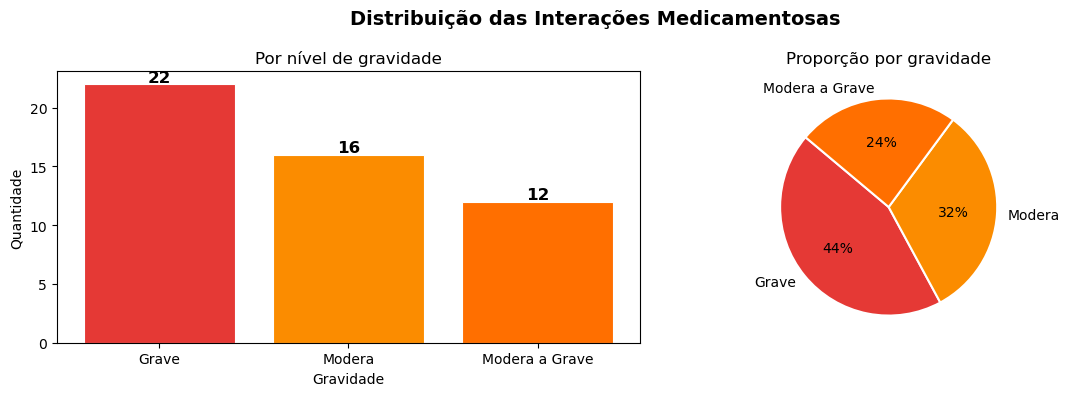

Gráfico salvo: grafico_gravidade.png


In [5]:
cores = {
    "Grave":          "#E53935",
    "Modera a Grave": "#FF6F00",
    "Modera":         "#FB8C00"
}

contagem = df["gravidade"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribuição das Interações Medicamentosas", fontsize=14, fontweight="bold")

# Gráfico de barras
bars = axes[0].bar(
    contagem.index, contagem.values,
    color=[cores[g] for g in contagem.index],
    edgecolor="white", linewidth=0.8
)
axes[0].set_title("Por nível de gravidade")
axes[0].set_xlabel("Gravidade")
axes[0].set_ylabel("Quantidade")
for bar, val in zip(bars, contagem.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        str(val), ha="center", fontweight="bold", fontsize=12
    )

# Gráfico de pizza
axes[1].pie(
    contagem.values,
    labels=contagem.index,
    colors=[cores[g] for g in contagem.index],
    autopct="%1.0f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Proporção por gravidade")

plt.tight_layout()
plt.savefig("grafico_gravidade.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: grafico_gravidade.png")

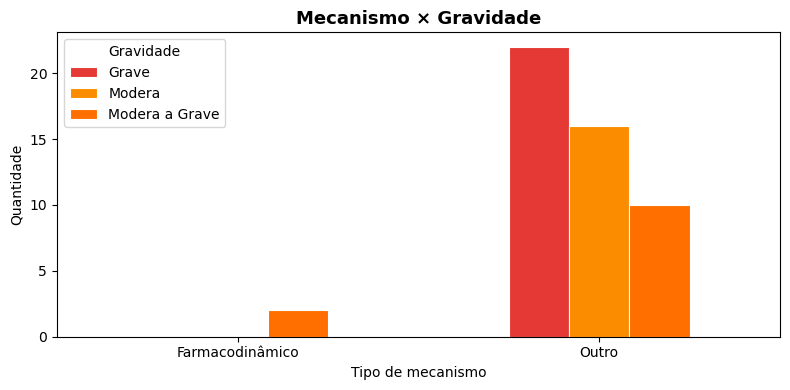

In [6]:
# Extrair tipo de mecanismo (farmacocinético vs farmacodinâmico)
df["tipo_mecanismo"] = df["mecanismo"].apply(
    lambda x: "Farmacocinético"  if "cin" in x.lower()
         else "Farmacodinâmico"  if "din" in x.lower()
         else "Outro"
)

fig, ax = plt.subplots(figsize=(8, 4))
cross = pd.crosstab(df["tipo_mecanismo"], df["gravidade"])
cross.plot(
    kind="bar", ax=ax,
    color=[cores.get(c, "#999") for c in cross.columns],
    edgecolor="white", linewidth=0.8
)
ax.set_title("Mecanismo × Gravidade", fontsize=13, fontweight="bold")
ax.set_xlabel("Tipo de mecanismo")
ax.set_ylabel("Quantidade")
ax.legend(title="Gravidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("grafico_mecanismo.png", dpi=150, bbox_inches="tight")
plt.show()

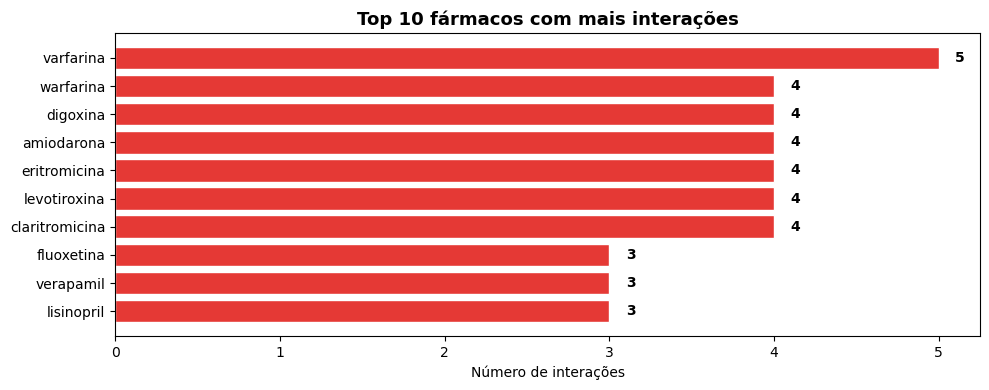

In [7]:
# Contar quantas interações cada fármaco aparece
todos = pd.concat([df["farmaco_1"], df["farmaco_2"]])
top10 = todos.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color="#E53935", edgecolor="white")
ax.set_title("Top 10 fármacos com mais interações", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de interações")
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontweight="bold")
plt.tight_layout()
plt.savefig("grafico_top10.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
## 🕸️ Rede Interativa de Interações

#Cada **nó** é um fármaco — tamanho e cor indicam o score de risco total.  
#Cada **aresta** é uma interação — cor e espessura indicam a gravidade.  
#**Passe o mouse** sobre nós e arestas para ver detalhes clínicos completos.

In [9]:
from pyvis.network import Network
from IPython.display import IFrame

# ── Configuração visual ───────────────────────────────────────
COR_ARESTA = {"Grave": "#E53935", "Modera a Grave": "#FF6F00", "Modera": "#FB8C00"}
ESPESSURA  = {"Grave": 5, "Modera a Grave": 3, "Modera": 1.8}
ICONE      = {"Grave": "[GRAVE]", "Modera a Grave": "[MOD-GRAVE]", "Modera": "[MODERADA]"}
PESO       = {"Grave": 3, "Modera a Grave": 2, "Modera": 1}

# ── Score de risco por fármaco ────────────────────────────────
score = {}
for _, r in df.iterrows():
    p = PESO.get(r["gravidade"], 1)
    score[r["farmaco_1"]] = score.get(r["farmaco_1"], 0) + p
    score[r["farmaco_2"]] = score.get(r["farmaco_2"], 0) + p

def tamanho(f): return max(20, min(score.get(f, 1) * 5, 65))
def cor_no(f):
    s = score.get(f, 1)
    if s >= 12: return "#B71C1C"
    if s >= 7:  return "#E53935"
    if s >= 4:  return "#FF6F00"
    if s >= 2:  return "#FB8C00"
    return "#66BB6A"

# ── Construir rede ────────────────────────────────────────────
net = Network(height="680px", width="100%", bgcolor="#1a1a2e",
              font_color="#EEEEEE", notebook=True, cdn_resources="in_line")
net.set_options("""{
  "physics": {"forceAtlas2Based": {"gravitationalConstant": -70,
    "centralGravity": 0.006, "springLength": 160,
    "springConstant": 0.04, "damping": 0.6},
    "solver": "forceAtlas2Based",
    "stabilization": {"iterations": 250}},
  "interaction": {"hover": true, "tooltipDelay": 80},
  "edges": {"smooth": {"type": "dynamic"}},
  "nodes": {"font": {"size": 12, "face": "Arial"}}
}""")

# ── Adicionar nós ─────────────────────────────────────────────
for f in pd.concat([df["farmaco_1"], df["farmaco_2"]]).unique():
    sub = df[(df.farmaco_1 == f) | (df.farmaco_2 == f)]
    net.add_node(f, label=f,
        title=(f"FARMACO: {f.upper()}\n"
               f"Total: {len(sub)} interacoes\n"
               f"Graves: {len(sub[sub.gravidade=='Grave'])}\n"
               f"Score de risco: {score.get(f,0)}"),
        size=tamanho(f), color=cor_no(f), borderWidth=2)

# ── Adicionar arestas ─────────────────────────────────────────
for _, r in df.iterrows():
    grav = r["gravidade"]
    net.add_edge(r["farmaco_1"], r["farmaco_2"],
        title=(f"{ICONE.get(grav,'')} {grav}\n"
               f"Mecanismo: {r['mecanismo']}\n"
               f"Conduta: {r['conduta']}"),
        color=COR_ARESTA.get(grav, "#999"),
        width=ESPESSURA.get(grav, 2))

# ── Salvar em UTF-8 e exibir ──────────────────────────────────
html_content = net.generate_html()
with open("grafo_interacoes.html", "w", encoding="utf-8") as f:
    f.write(html_content)
print("Arquivo salvo: grafo_interacoes.html")

IFrame("grafo_interacoes.html", width="100%", height="680px")

Arquivo salvo: grafo_interacoes.html
